# Tool calling

In [1]:
import os
import getpass

os.environ["GROQ_API_KEY"] = getpass.getpass("Groq API key: ")
print("Key set (hidden for security).")

Key set (hidden for security).


In [ ]:
import os
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = ""

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile"
)

# Quick sanity check
response = llm.invoke("Say hello in one sentence.")
print(response.content)

Hello, it's nice to meet you and I'm here to help with any questions or topics you'd like to discuss.


In [3]:
from langchain_core.tools import tool

In [4]:
@tool
def add(a:float,b:float)->float:
    "add the two numbers"
    return a+b

@tool
def multply(a:float,b:float)->float:
    "multiplay two numbers"
    return a*b


In [5]:
@tool
def get_wheather(city:str)->str:
    "get wheather for specific city"

    fake_data = {
        "london":   "Cloudy, 15 C, light rain.",
        "paris":    "Sunny, 22 C, clear skies.",
        "new york": "Partly cloudy, 18 C, mild breeze.",
        "tokyo":    "Humid, 28 C, mostly sunny.",
    }

    key = city.lower().strip()

    return fake_data.get(key,f'there is no wheather data avalible for {key}')

In [6]:
print('Tool_name',add.name)
print('Discription',add.description)
print('args',add.args)
print('--------')
print('Tool_name',get_wheather.name)
print('Discription',get_wheather.description)
print('args',get_wheather.args)

Tool_name add
Discription add the two numbers
args {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}
--------
Tool_name get_wheather
Discription get wheather for specific city
args {'city': {'title': 'City', 'type': 'string'}}


In [7]:
tools = [add,multply,get_wheather]

llm_bind_tool = llm.bind_tools(tools)

In [8]:
from langchain_core.messages import HumanMessage

test_txt = HumanMessage(content='what is the add of 3 , 7 and muiltply of the the ans od addition and 4')
response = llm_bind_tool.invoke([test_txt])

print(response)
print("content",response.content)
print('tool_call',response.tool_calls)

content='' additional_kwargs={'tool_calls': [{'id': 'pfzhy224d', 'function': {'arguments': '{"a":3,"b":7}', 'name': 'add'}, 'type': 'function'}, {'id': '1x9y3ama6', 'function': {'arguments': '{"a":10,"b":4}', 'name': 'multply'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 348, 'total_tokens': 385, 'completion_time': 0.101519017, 'completion_tokens_details': None, 'prompt_time': 0.086598558, 'prompt_tokens_details': None, 'queue_time': 0.405079481, 'total_time': 0.188117575}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019ede9b-dd91-7953-9506-599f3432122d-0' tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 7}, 'id': 'pfzhy224d', 'type': 'tool_call'}, {'name': 'multply', 'args': {'a': 10, 'b': 4}, 'id': '1x9y3ama6', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_t

In [9]:
from langchain_core.messages import HumanMessage

plain_txt = HumanMessage(content='what wheather in india')
response = llm_bind_tool.invoke([plain_txt])

print(response)
print("content",response.content)
print('tool_call',response.tool_calls)

content='' additional_kwargs={'tool_calls': [{'id': 'a7yh3j1mj', 'function': {'arguments': '{"city":"India"}', 'name': 'get_wheather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 329, 'total_tokens': 345, 'completion_time': 0.049716832, 'completion_tokens_details': None, 'prompt_time': 0.027405466, 'prompt_tokens_details': None, 'queue_time': 0.388958354, 'total_time': 0.077122298}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019ede9b-e052-7081-bf8b-5769d7131908-0' tool_calls=[{'name': 'get_wheather', 'args': {'city': 'India'}, 'id': 'a7yh3j1mj', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 329, 'output_tokens': 16, 'total_tokens': 345}
content 
tool_call [{'name': 'get_wheather', 'args': {'city': 'India'}, 'id': 'a7yh3j1mj', 'type': 'tool_call'}]


In [10]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

In [11]:
tools = [add,multply,get_wheather]

llm_bind_tool = llm.bind_tools(tools)

In [12]:
def chat_bot(state : MessagesState)->dict:
    response = llm_bind_tool.invoke(state['messages'])
    return {'messages':[response]}

In [13]:
tools = ToolNode(tools)

In [14]:
builder = StateGraph(MessagesState)

In [15]:
builder.add_node('chat_bot',chat_bot)
builder.add_node('tools',tools)


In [16]:
builder.add_edge(START,'chat_bot')

builder.add_conditional_edges('chat_bot',tools_condition)

builder.add_edge('tools','chat_bot')

graph = builder.compile()

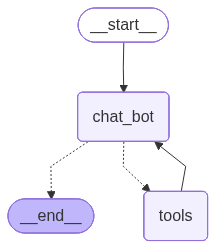

In [17]:

try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [19]:
from langchain_core.messages import HumanMessage

question = "What is 3 times 12? Then add 5 to the result."

print("=" * 55)
print("Question:", question)
print("=" * 55)

for step in graph.stream(
    {"messages": [HumanMessage(content=question)]},
    stream_mode="values",
):
    last = step["messages"][-1]   # most recent message in the state
    last.pretty_print()           # nicely formatted output
    print("-" * 55)

Question: What is 3 times 12? Then add 5 to the result.
================================ Human Message =================================

What is 3 times 12? Then add 5 to the result.
-------------------------------------------------------


BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=multply({"a": 3, "b": 12})</function>\n'}}